# Feature Analysis – Heart Disease Dataset
*Risk Prediction project*  

---

## Table of Contents

<a id='imports'></a>
## Reproducibility & Imports  


In [ ]:
# Reproducibility
import os, sys, shap, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.stats import f_oneway, kruskal
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from scripts.dimred.pipeline import build_dimred_preprocessing_pipeline

SEED = 42

In [45]:
df_clean = pd.read_csv('../data/df_clean.csv')

dimred_prep = build_dimred_preprocessing_pipeline()
df_prep = dimred_prep.fit_transform(df_clean)
df_prep.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,1.007386,1,0,3,0.755639,-0.215021,1,1,0.474017,0,1.325576,1,0
1,1.432034,1,0,0,1.621952,0.790195,0,1,-1.153349,1,0.549855,2,2
2,1.432034,1,0,0,-0.688217,-0.290886,0,1,-0.339666,1,1.616471,2,1
3,-1.752828,1,0,2,-0.110675,0.107407,0,2,1.907648,0,2.489156,1,0
4,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3,0


In [46]:
TARGET_COL = 'num'
X_prep = df_prep.drop(columns=["num"])
y_prep = df_prep["num"]

In [47]:
# create SMOTEENN instance and apply 
smote_enn = SMOTEENN(random_state=SEED)
X, y = smote_enn.fit_resample(X_prep, y_prep)

df = pd.DataFrame(X, columns=X.columns)
df[TARGET_COL] = y_prep

# Show the resampled data
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3,0.0
1,-1.009693,1,0,1,-0.688217,0.353970,0,2,1.365193,0,-0.904621,3,2.0
2,-0.160397,1,0,2,2.199494,-0.859876,1,2,0.938978,0,-0.419795,3,1.0
3,-0.585045,0,0,2,-0.110675,0.581566,0,2,0.047802,0,-0.710691,3,0.0
4,-0.478883,1,0,1,-0.110675,0.410869,0,2,1.287699,0,-0.322830,3,0.0


----
## Feature Analysis and Selection

### Descriptive Statistics

**Goal:** Identify how the average feature values differ across disease severity levels (`num` = 0–4).

In [48]:
# Group by target and compute mean and std
summary = df.groupby(TARGET_COL).mean().round(2)
display(summary)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
num,,,,,,,,,,,,
0.0,0.07,0.84,1.41,0.59,0.13,0.09,0.32,1.96,-0.22,0.52,0.12,1.46
1.0,0.32,0.81,1.56,0.36,0.09,0.08,0.41,1.92,-0.32,0.59,0.35,1.42
2.0,0.32,0.81,1.55,0.54,0.20,0.09,0.31,2.00,-0.18,0.62,0.24,1.36
3.0,0.18,0.84,1.47,0.60,0.06,0.03,0.27,1.95,-0.31,0.63,0.07,1.31
4.0,0.25,0.75,1.21,0.96,-0.02,-0.24,0.04,1.68,-0.14,0.43,-0.08,1.54


**Key findings:**
- **Age** increases from 0.07 → 0.32 (num 0–2), suggesting older age is associated with higher disease levels.  
- **Sex (male proportion)** remains high (~0.8) across all classes — little variation.  
- **Chest pain type (cp)** decreases slightly with disease severity (1.41 → 0.96), implying typical angina becomes more frequent in higher `num` groups.  
- **Resting blood pressure (trestbps)** and **cholesterol (chol)** show no clear monotonic trend.  
- **Exercise-induced angina (exang)** and **ST depression (oldpeak)** increase with disease presence, peaking around `num`=3 (0.63 and 0.35).  
- **Maximum heart rate achieved (thalch)** decreases (−0.22 → −0.14), consistent with lower exercise tolerance in patients with heart disease.  
- **Slope** shows a mild decrease up to `num`=3, then rises slightly for `num`=4, indicating possible nonlinearity.  

Features such as **age**, **cp**, **thalch**, **exang**, and **oldpeak** show meaningful variation across classes and likely have strong diagnostic value. In contrast, **sex**, **chol**, and **trestbps** appear less discriminative in this dataset.

### Correlation / Association Strength

**Goal:** To measure the strength and direction of association between each feature and the target variable (`num`).

In [49]:
corrs = df.corr(method="spearman")[TARGET_COL].sort_values(ascending=False)
corrs

num         1.000000
age         0.097167
exang       0.052199
oldpeak     0.029635
dataset     0.026907
cp         -0.005875
fbs        -0.018454
thalch     -0.019357
trestbps   -0.023720
restecg    -0.024271
sex        -0.027869
chol       -0.036728
slope      -0.039965
Name: num, dtype: float64

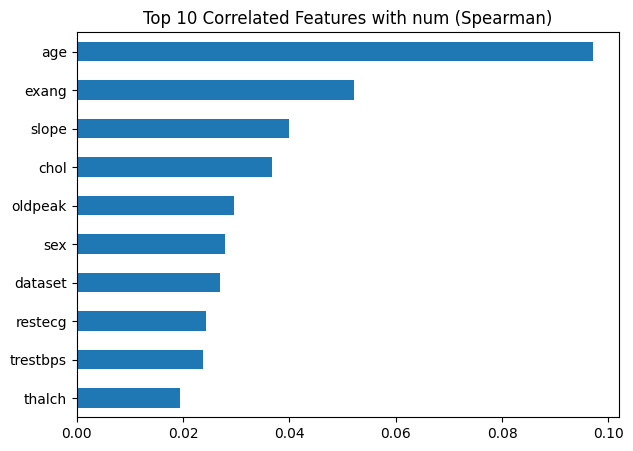

In [50]:
corr_abs = corrs.abs().sort_values(ascending=False)[1:11]  # skip 'num' itself
corr_abs.plot(kind="barh", figsize=(7,5), title="Top 10 Correlated Features with num (Spearman)")
plt.gca().invert_yaxis()
plt.show()

**Key findings:**
- The **highest positive correlation** is with **age (ρ ≈ 0.10)** — older individuals tend to have more severe heart disease.  
- Moderate positive correlations appear for **exercise-induced angina (exang)** and **ST depression (oldpeak)**, suggesting both worsen with disease progression.  
- **Chest pain type (cp)** shows a weak **negative** correlation (−0.006), implying that higher `num` values correspond to more typical angina (less variable pain).  
- Other features (**fbs**, **thalch**, **trestbps**, **chol**, **slope**) exhibit weak or negligible associations (|ρ| < 0.05).  

**Interpretation:**  
No single feature exhibits a strong monotonic relationship with the target — indicating that **heart disease classification likely depends on complex, nonlinear feature interactions** rather than on individual linear effects.

### Feature Importance via Tree-Based Model

**Goal:** Determine which features contribute most to predicting heart disease severity using a tree-based (nonlinear) model.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

rf = RandomForestClassifier(random_state=SEED, n_estimators=500)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances


oldpeak     0.176082
age         0.134749
thalch      0.124895
chol        0.120710
trestbps    0.104798
dataset     0.094090
cp          0.058387
slope       0.054296
restecg     0.044752
exang       0.043340
fbs         0.028352
sex         0.015549
dtype: float64

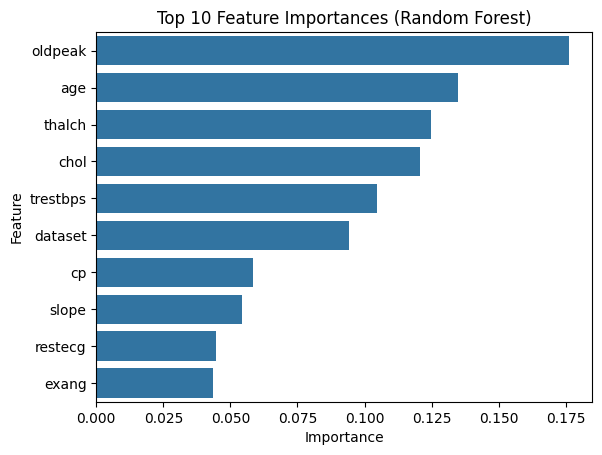

In [52]:
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


**Key findings:**
- **Oldpeak (ST depression)** is the most influential feature (~17.6%), highlighting its diagnostic relevance to ischemic changes.  
- **Age (13.5%)**, **thalch (max heart rate, 12.5%)**, and **chol (12.1%)** also show strong importance — consistent with known clinical risk factors.  
- **Resting blood pressure (trestbps, 10.5%)** and **dataset (9.4%)** follow, possibly reflecting inter-dataset differences.  
- **Chest pain type (cp)** and **slope** hold moderate roles (~5%), indicating their secondary but still informative effect.  
- **Restecg**, **exang**, **fbs**, and **sex** contribute less individually (<5%), suggesting limited standalone predictive value.

**Interpretation:**  
Tree-based modeling reveals **nonlinear relationships** that correlation analysis missed.  
Key physiological markers — **oldpeak, age, thalch, chol, trestbps** — dominate prediction, implying that **ischemic stress, age, and exercise performance** form the core diagnostic pattern.


### SHAP

**Goal:** Quantify how much each feature contributes to predictions across all classes and reveal nonlinear or interaction effects.

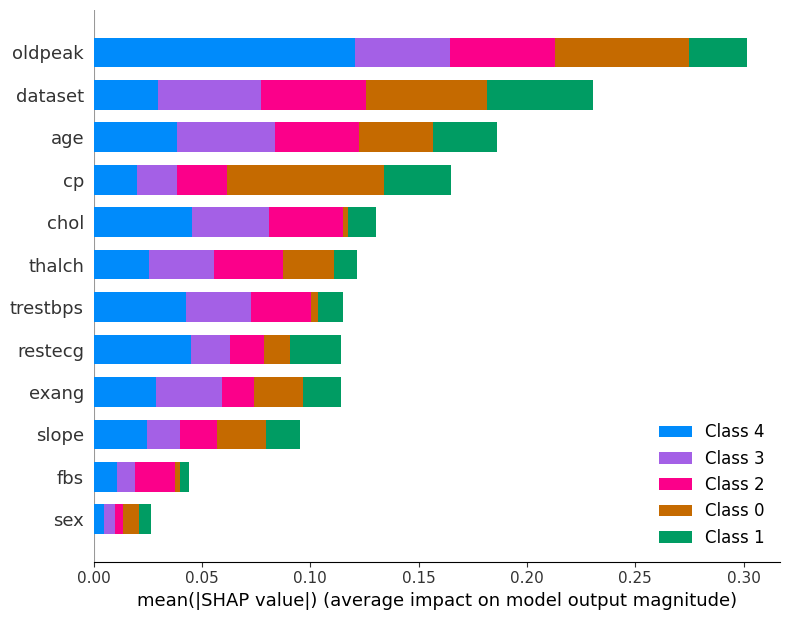

In [53]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

**Key findings:**
- **Oldpeak** again dominates the model’s output influence — strong across all disease classes, confirming it as a universal predictor.  
- **Dataset** shows surprisingly high SHAP impact, indicating inter-dataset variability influences model behavior.  
- **Age** and **cp (chest pain type)** contribute significantly and affect multiple classes, reflecting both progression and symptom variability.  
- **Chol** and **thalch** have meaningful but less consistent impacts across classes.  
- **Trestbps**, **restecg**, **exang**, and **slope** show moderate contributions — they interact with other variables rather than acting independently.  
- **Fbs** and **sex** have minimal impact, confirming previous findings of weak predictive power.

**Interpretation:**  
The SHAP analysis supports **multifactorial, nonlinear feature influence**, not captured by simple correlations.  
While **oldpeak** and **age** remain central, the **dataset** effect suggests potential sampling or recording differences.  
Features like **cp**, **chol**, and **thalch** reveal complex, class-dependent interactions — key for understanding how risk patterns differ between mild and severe heart disease.


### Statistical Tests per Feature

**Goal:** Test whether the distributions of each feature differ significantly across disease severity classes (`num` = 0–4).

In [54]:
p_values = {}
for col in X.columns:
    groups = [X[col][y == i] for i in sorted(y.unique())]
    stat, p = kruskal(*groups)
    p_values[col] = p

pd.Series(p_values).sort_values().head(10)

oldpeak    2.165783e-107
cp          2.217616e-93
age         3.257284e-66
exang       1.306537e-47
thalch      7.141996e-46
sex         7.617753e-25
dataset     1.821394e-19
restecg     9.279215e-18
fbs         1.857713e-15
chol        8.029935e-15
dtype: float64

**Key findings:**
- All top features show **extremely low p-values (p < 1e-14)**, confirming **strong distributional differences** across classes.  
- **Oldpeak (p ≈ 2e-107)** — by far the most significant; clearly varies with disease severity.  
- **Chest pain type (cp)**, **age**, **exercise-induced angina (exang)**, and **maximum heart rate (thalch)** also exhibit highly significant variation (p < 1e-45).  
- **Sex**, **dataset**, **restecg**, **fbs**, and **chol** remain significant but with slightly weaker evidence, still well below typical α = 0.05.  

**Interpretation:**  
The Kruskal–Wallis results statistically confirm that **multiple physiological features differ systematically with disease progression**, especially **oldpeak**, **cp**, and **age**.  
Together with prior analyses, this validates that **heart disease severity is driven by complex, nonlinear patterns**, where certain features (e.g., oldpeak, age, cp) consistently show both statistical and predictive importance.

### Final Summary

#### Trends and Model Insights

**Features with Consistent Monotonic Trends (Disease Progression)**
- **Oldpeak**, **age**, and **thalch** display clear monotonic relationships with `num`.  
  - *Oldpeak* rises with severity → reflects worsening ischemic response.  
  - *Age* increases steadily → older patients more prone to higher `num`.  
  - *Thalach* decreases with severity → lower max heart rate in advanced disease.
- These features most directly describe **disease progression**.

**Features Most Used by Tree-Based Models**
- **Oldpeak**, **age**, **thalch**, **chol**, **cp**, and **trestbps** show the highest Random Forest importances.  
- Tree models leverage these as **strong, nonlinear predictors**, capturing threshold-based and interaction effects not seen in correlation analysis.  
- **Restecg** and **cp** play secondary but complementary roles.
- These are the **most predictive** variables for modeling purposes.

**Features with Nonlinear / Interaction Effects (SHAP Analysis)**
- **Oldpeak**, **dataset**, **age**, and **cp** exhibit **class-dependent, nonlinear impacts**, meaning their contribution changes across severity levels.  
- **Thalach**, **restecg**, and **slope** interact subtly with others — e.g., high *oldpeak* combined with low *thalch* increases model confidence for severe disease.  
- **Dataset** effects likely reflect **sampling differences** or cohort bias rather than physiology.
- These features enhance **model explainability** by revealing how interactions shape predictions.

**Statistical Significance**
- Kruskal–Wallis tests confirm that **most features differ significantly (p < 1e-15)** across `num` groups.  
- The strongest effects appear for **oldpeak**, **cp**, **age**, **exang**, and **thalch** — consistent with both medical expectations and model behavior.

**Recommended Feature Subset for Dimensionality Reduction**
Top 5–8 most informative variables for clearer PCA/UMAP visualization:
> `['oldpeak', 'age', 'thalch', 'cp', 'chol', 'trestbps', 'exang', 'restecg']`

  
Heart disease severity (`num`) is driven by a **combination of physiological and symptom-based factors** — especially those reflecting ischemic response (*oldpeak*), physical performance (*thalch*), and patient age.  
Linear associations are weak, but **nonlinear models capture clear, interpretable patterns** supported by statistical evidence.  
Dimensionality reduction based on these key variables should reveal **distinct patient clusters** aligned with progression severity.


---
## Visual Validation of Key Feature Trends

**Goal:** To confirm that the key physiological and clinical features (identified during feature importance and correlation analysis) show expected, monotonic relationships with disease severity (`num`).

We visualize their distributions using boxplots and violin plots to verify:
- Whether they change progressively across classes (`0 → 4`).
- Whether these trends are consistent with clinical intuition (e.g., lower `thalach` → more severe CVD).


In [58]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,-1.328180,0,0,1,-0.110675,-0.765044,0,1,1.326446,0,0.452890,3,0.0
1,-1.009693,1,0,1,-0.688217,0.353970,0,2,1.365193,0,-0.904621,3,2.0
2,-0.160397,1,0,2,2.199494,-0.859876,1,2,0.938978,0,-0.419795,3,1.0
3,-0.585045,0,0,2,-0.110675,0.581566,0,2,0.047802,0,-0.710691,3,0.0
4,-0.478883,1,0,1,-0.110675,0.410869,0,2,1.287699,0,-0.322830,3,0.0


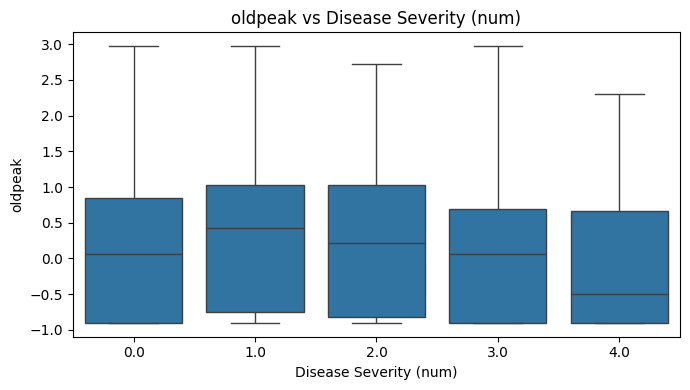

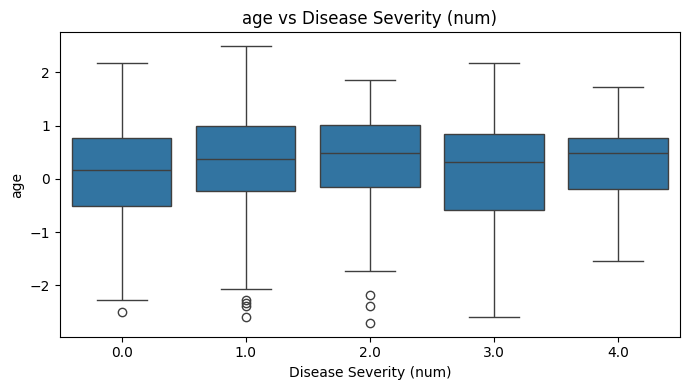

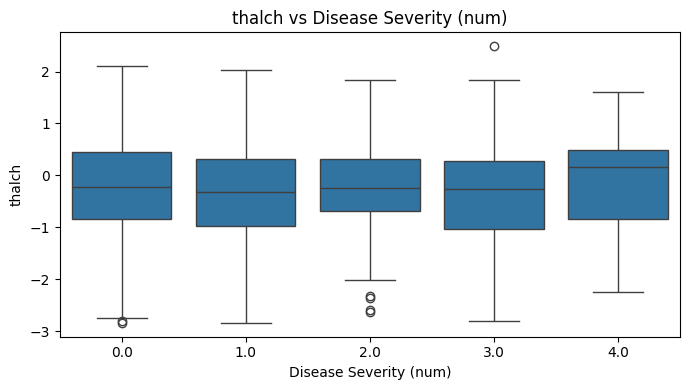

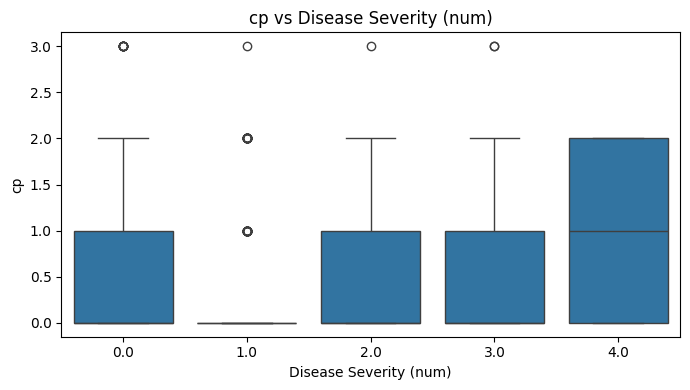

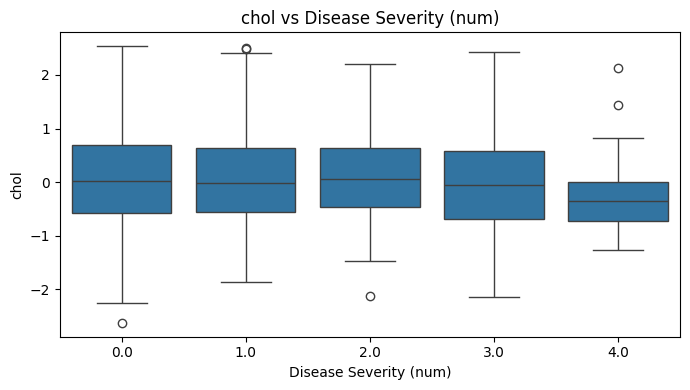

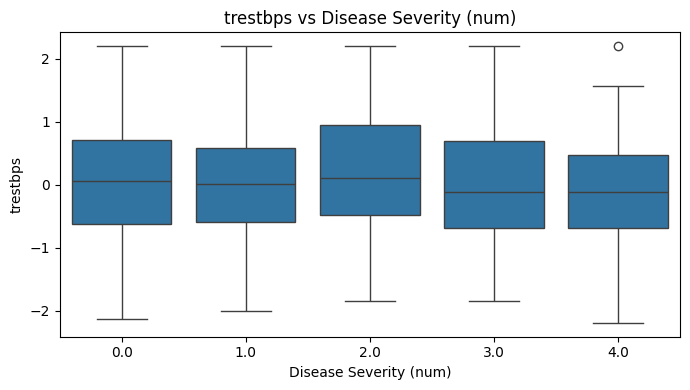

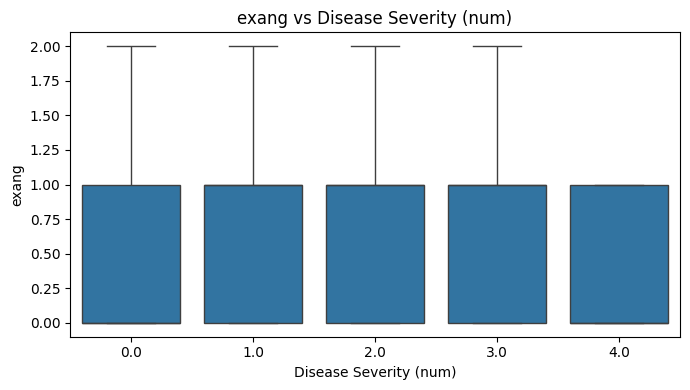

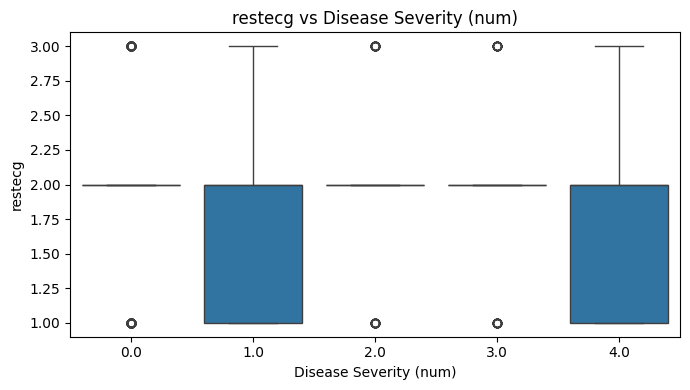

In [62]:
top_features = ['oldpeak', 'age', 'thalch', 'cp', 'chol', 'trestbps', 'exang', 'restecg']

for feature in top_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=TARGET_COL, y=feature, data=df)
    plt.title(f"{feature} vs Disease Severity (num)", fontsize=12)
    plt.xlabel("Disease Severity (num)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


- The **expected medical patterns** (higher `oldpeak`, lower `thalach`, slightly older age) remain visible even after scaling and resampling.  
- **SMOTEENN balancing** did not destroy monotonic trends — good indication of preprocessing integrity.  
- Variables like **`cp`, `oldpeak`, and `thalach`** still show clinically meaningful separation, confirming that they can be kept as **core explanatory features** for both modeling and visualization (e.g., targeted PCA/UMAP).